# Explorative sales analysis

This larger notebook creates synthetic sales data, filters it with
widgets, and shows grouped tables and plots.


In [1]:
%matplotlib inline


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

dates = pd.date_range("2026-01-01", periods=60, freq="D")
regions = ["north", "south", "east", "west"]
categories = ["hardware", "software", "service"]

rows = []
for index, date in enumerate(dates):
    region = regions[index % len(regions)]
    category = categories[index % len(categories)]
    revenue = 100 + (index * 7) % 80
    cost = 45 + (index * 5) % 40
    rows.append({
        "date": date,
        "region": region,
        "category": category,
        "revenue": revenue,
        "cost": cost,
    })

sales = pd.DataFrame(rows)
sales["profit"] = sales["revenue"] - sales["cost"]
display(sales.head())


,date,region,category,revenue,cost,profit
0,2026-01-01,north,hardware,100,45,55
1,2026-01-02,south,software,107,50,57
2,2026-01-03,east,service,114,55,59
3,2026-01-04,west,hardware,121,60,61
4,2026-01-05,north,software,128,65,63


## Interactive filter setup

The next cells create controls for selecting a region and a minimum
revenue. The filtered data should update the summary used for the
chart.


In [3]:
region_dropdown = widgets.Dropdown(
    options=["all"] + sorted(sales["region"].unique()),
    value="all",
    description="Region:",
)
min_revenue = widgets.IntSlider(
    value=120,
    min=80,
    max=180,
    step=10,
    description="Min rev:",
)

display(region_dropdown)
display(min_revenue)


Dropdown(description='Region:', options=('all', 'east', 'north', 'south', 'west'), value='all')

IntSlider(value=120, description='Min rev:', max=180, min=80, step=10)

## Aggregated sales summary

This step groups the filtered rows by category and compares average
revenue with average profit.


In [4]:
filtered = sales[sales["revenue"] >= min_revenue.value]
if region_dropdown.value != "all":
    filtered = filtered[filtered["region"] == region_dropdown.value]

summary = filtered.groupby("category")[["revenue", "profit"]].mean()
display(summary)


,revenue,profit
category,,
hardware,150.000000,85.666667
service,149.285714,90.714286
software,150.714286,87.857143


## Profit chart

The final chart should make it easy to compare which category has the
highest average profit after filtering.


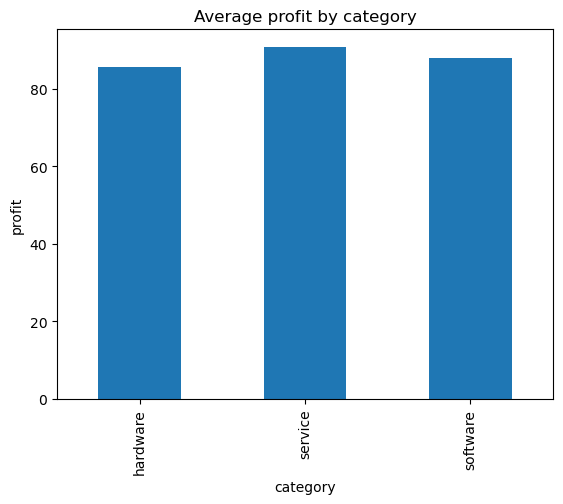

CPU times: total: 125 ms
Wall time: 134 ms


: 

In [ ]:
%%time
ax = summary["profit"].plot(kind="bar", title="Average profit by category")
ax.set_ylabel("profit")
plt.show()
